In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import duckdb
import seaborn as sns
sns.set_theme(style='ticks', font_scale=1.5, palette=sns.color_palette(),)
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import polars as pl
import torch
import numpy as np

import conf.conf
import dafm.datasets
import dafm.observe
import dafm.plots
import dafm.utils

In [3]:
duckdb.sql("""
attach '../runs.sqlite';
use runs;
""")

# Dataset

In [4]:
dataset_rows = duckdb.sql(r"""
select
    DynamicalSystemImpl.id
    --columns(* exclude(sa_inheritance)) as 'dataset_\0',
    --sa_inheritance as dataset_name,
from DynamicalSystemImpl
join DynamicalSystem on DynamicalSystemImpl.DynamicalSystem = DynamicalSystem.id
join Rotation2D on DynamicalSystem.id = Rotation2D.id
where true
and radius = 1.
""")
dataset_rows.show(max_width=120)

┌───────┐
│  id   │
│ int64 │
├───────┤
│    12 │
└───────┘



In [5]:
da_setting_rows = duckdb.sql("""
select
    *,
    if(ReferenceFilter is null, 'rmse', 'rmse_from_reference_filter') as loss_name,
from DataAssimilationSetting
where true
and DynamicalSystemImpl in (select id from dataset_rows)
""")
da_setting_rows

┌─────────┬───────────────┬────────────────────────────┬───────┬─────────────────────┬──────────┬─────────────────┬─────────────────────────────────────┬────────────────────────────┐
│  split  │ obs_noise_std │ observe_every_n_time_steps │  id   │ DynamicalSystemImpl │ Splitter │ ReferenceFilter │ ensemble_initial_mean_is_true_state │         loss_name          │
│ varchar │    double     │           int64            │ int64 │        int64        │  int64   │      int64      │                int64                │          varchar           │
├─────────┼───────────────┼────────────────────────────┼───────┼─────────────────────┼──────────┼─────────────────┼─────────────────────────────────────┼────────────────────────────┤
│ TRAIN   │           0.5 │                          1 │    44 │                  12 │       10 │            NULL │                                   1 │ rmse                       │
│ TRAIN   │           0.5 │                          1 │    45 │                  12 

In [6]:
rows = duckdb.sql("""
select
    Conf.*,
from Conf
join da_setting_rows on Conf.DataAssimilationSetting = da_setting_rows.id
join Filter on Conf.Filter = Filter.id
where true
and save_ensemble_stats
""")
rows.show(max_width=120)

┌──────────┬────────────┬─────────────────────┬───────┬─────────────────────────┬────────┐
│  alt_id  │  rng_seed  │ save_ensemble_stats │  id   │ DataAssimilationSetting │ Filter │
│ varchar  │   int64    │        int64        │ int64 │          int64          │ int64  │
├──────────┼────────────┼─────────────────────┼───────┼─────────────────────────┼────────┤
│ szpbntr6 │ 2376999025 │                   1 │ 11232 │                      44 │  11045 │
│ 4jrybvo4 │ 2376999025 │                   1 │ 11293 │                      45 │  11220 │
└──────────┴────────────┴─────────────────────┴───────┴─────────────────────────┴────────┘



# Filter

In [7]:
filter_kf = duckdb.sql("""
select
    alt_id,
    filter_name as hue,
    hue as style,
from rows
join filter_id_kf using (Filter)
""")
filter_kf

┌──────────┬─────────┬─────────┐
│  alt_id  │   hue   │  style  │
│ varchar  │ varchar │ varchar │
├──────────┼─────────┼─────────┤
│ szpbntr6 │ KF      │ KF      │
└──────────┴─────────┴─────────┘

In [8]:
filter_enff_f2p = duckdb.sql("""
select
    alt_id,
    filter_name as hue,
    hue as style,
from rows
join filter_id_enff_f2p using (Filter)
""")
filter_enff_f2p

┌──────────┬──────────┬──────────┐
│  alt_id  │   hue    │  style   │
│ varchar  │ varchar  │ varchar  │
├──────────┼──────────┼──────────┤
│ 4jrybvo4 │ EnFF-F2P │ EnFF-F2P │
└──────────┴──────────┴──────────┘

In [9]:
filters = duckdb.sql("""
select * from filter_kf
union
select * from filter_enff_f2p
""")
filters

┌──────────┬──────────┬──────────┐
│  alt_id  │   hue    │  style   │
│ varchar  │ varchar  │ varchar  │
├──────────┼──────────┼──────────┤
│ szpbntr6 │ KF       │ KF       │
│ 4jrybvo4 │ EnFF-F2P │ EnFF-F2P │
└──────────┴──────────┴──────────┘

In [10]:
dataset = None
x_min, x_max = None, None
dfs = []
obs_dfs = {}
with conf.conf.Session() as db:
    for alt_id in filters.pl()['alt_id']:
        cfg = db.query(conf.conf.Conf).filter_by(alt_id=alt_id).first()
        time_step_limit = cfg.setting.splitter.start_train + 130
        time_step_to_index = {ts: i for i, ts in enumerate(cfg.setting.observation_time_steps) if ts < time_step_limit}
        x, indices = map(list, zip(*time_step_to_index.items()))
        if x_min is None or x_min > min(x):
            x_min = min(x)
        if x_max is None or x_max < max(x):
            x_max = max(x)
        if dataset is None:
            dataset = dafm.datasets.get_dataset(cfg.setting.dataset, np.random.default_rng(dafm.utils.RNG_RANDBITS[cfg.setting.dataset.rng_seed]['DATASET']), 'cpu')
            dataset.prepare_data()
            dataset.setup('fit')
        mean = torch.load(cfg.run_dir/'ensemble_mean.pt', weights_only=True)[indices]
        covariance = torch.load(cfg.run_dir/'ensemble_covariance.pt', weights_only=True)
        state_names = [f'$x_{i+1}$' for i in range(mean.shape[1])]
        cov_names = [f'$C_{{{i+1}{i+1}}}$' for i in range(mean.shape[1])]
        df = pl.DataFrame(dict(
            alt_id=alt_id,
            # filter_name=filter_name,
            # observe_every_n_time_steps=cfg.observe_every_n_time_steps,
            # rmse_from_true=(mean - true_state).square().mean(1).sqrt().numpy(),
            # rmse_from_bpf=(mean - bpf_mean).square().mean(1).sqrt().numpy(),
            # covariance_error=((covariance - bpf_covariance).square().sum((1, 2)).sqrt() / bpf_mean.shape[-1]).numpy(),  # divide by dimension, not dimension^2, for dimension average
            **{state_names[i]: x.numpy() for i, x in enumerate(mean.mT)},
            **{cov_names[i]: covariance[:, i, i].numpy() for i in range(mean.shape[1])},
            x=x,
        )).lazy()
        dfs.append(df)
        if cfg.setting.id not in obs_dfs:
            observation = torch.load(cfg.setting.cache_dir/f'{cfg.setting.id}_observations.pt', weights_only=True).squeeze(1)
            obs_dfs[cfg.setting.id] = pl.DataFrame(dict(
                DataAssimilationSetting=cfg.setting.id,
                **{state_names[i]: x.numpy() for i, x in enumerate(observation[indices].mT)},
                hue='Obs',
                style='Obs',
                col=cfg.setting.observe_every_n_time_steps,
                x=x,
            )).lazy()
true_df = pl.DataFrame(dict(
    **{f'$x_{i+1}$': x.numpy() for i, x in enumerate(dataset[x_min:x_max+1].squeeze(1).mT)},
)).with_columns(x=pl.int_range(x_min, x_max+1)).unpivot(
    on=state_names,
    index='x',
    variable_name='row',
    value_name='y',
)
print(true_df)
df = (
    pl.concat(dfs)
    .unpivot(
        on=state_names,
        index=['alt_id', 'x', *cov_names],
        variable_name='row',
        value_name='y',
    )
    .collect()
)
del dfs
cov_df = df
df = df.drop(cov_names)
print(df)
print(cov_df)
obs_df = (
    pl.concat(obs_dfs.values())
    .unpivot(
        on=state_names,
        index=['DataAssimilationSetting', 'col', 'x'],
        variable_name='row',
        value_name='y',
    )
    .collect()
)
del obs_dfs
obs_df

shape: (100, 3)
┌─────┬───────┬───────────┐
│ x   ┆ row   ┆ y         │
│ --- ┆ ---   ┆ ---       │
│ i64 ┆ str   ┆ f32       │
╞═════╪═══════╪═══════════╡
│ 0   ┆ $x_1$ ┆ 1.0       │
│ 1   ┆ $x_1$ ┆ 0.926453  │
│ 2   ┆ $x_1$ ┆ 0.716632  │
│ 3   ┆ $x_1$ ┆ 0.401399  │
│ 4   ┆ $x_1$ ┆ 0.027123  │
│ …   ┆ …     ┆ …         │
│ 45  ┆ $x_2$ ┆ 0.996172  │
│ 46  ┆ $x_2$ ┆ 0.890003  │
│ 47  ┆ $x_2$ ┆ 0.65292   │
│ 48  ┆ $x_2$ ┆ 0.319797  │
│ 49  ┆ $x_2$ ┆ -0.060365 │
└─────┴───────┴───────────┘
shape: (200, 4)
┌──────────┬─────┬───────┬───────────┐
│ alt_id   ┆ x   ┆ row   ┆ y         │
│ ---      ┆ --- ┆ ---   ┆ ---       │
│ str      ┆ i64 ┆ str   ┆ f32       │
╞══════════╪═════╪═══════╪═══════════╡
│ 4jrybvo4 ┆ 0   ┆ $x_1$ ┆ 0.93196   │
│ 4jrybvo4 ┆ 1   ┆ $x_1$ ┆ 0.788069  │
│ 4jrybvo4 ┆ 2   ┆ $x_1$ ┆ 0.651663  │
│ 4jrybvo4 ┆ 3   ┆ $x_1$ ┆ 0.332073  │
│ 4jrybvo4 ┆ 4   ┆ $x_1$ ┆ -0.119717 │
│ …        ┆ …   ┆ …     ┆ …         │
│ szpbntr6 ┆ 45  ┆ $x_2$ ┆ 1.102948  │
│ szpbntr6 ┆ 46  ┆ $x_2$

DataAssimilationSetting,col,x,row,y
i32,i32,i64,str,f32
45,1,0,"""$x_1$""",1.413738
45,1,1,"""$x_1$""",0.478917
45,1,2,"""$x_1$""",1.633127
45,1,3,"""$x_1$""",1.046395
45,1,4,"""$x_1$""",-0.131365
…,…,…,…,…
44,1,45,"""$x_2$""",1.027265
44,1,46,"""$x_2$""",0.878075
44,1,47,"""$x_2$""",0.361229


shape: (200, 6)
┌──────────┬──────────┬──────────┬─────┬───────┬──────────┐
│ alt_id   ┆ hue      ┆ style    ┆ x   ┆ row   ┆ y        │
│ ---      ┆ ---      ┆ ---      ┆ --- ┆ ---   ┆ ---      │
│ str      ┆ str      ┆ str      ┆ i64 ┆ str   ┆ f32      │
╞══════════╪══════════╪══════════╪═════╪═══════╪══════════╡
│ szpbntr6 ┆ KF       ┆ KF       ┆ 0   ┆ $x_1$ ┆ 1.112409 │
│ szpbntr6 ┆ KF       ┆ KF       ┆ 49  ┆ $x_1$ ┆ 1.105356 │
│ szpbntr6 ┆ KF       ┆ KF       ┆ 1   ┆ $x_1$ ┆ 0.798202 │
│ szpbntr6 ┆ KF       ┆ KF       ┆ 2   ┆ $x_1$ ┆ 0.841842 │
│ szpbntr6 ┆ KF       ┆ KF       ┆ 3   ┆ $x_1$ ┆ 0.445386 │
│ …        ┆ …        ┆ …        ┆ …   ┆ …     ┆ …        │
│ 4jrybvo4 ┆ EnFF-F2P ┆ EnFF-F2P ┆ 44  ┆ $x_2$ ┆ 1.120517 │
│ 4jrybvo4 ┆ EnFF-F2P ┆ EnFF-F2P ┆ 45  ┆ $x_2$ ┆ 1.136844 │
│ 4jrybvo4 ┆ EnFF-F2P ┆ EnFF-F2P ┆ 46  ┆ $x_2$ ┆ 0.992799 │
│ 4jrybvo4 ┆ EnFF-F2P ┆ EnFF-F2P ┆ 47  ┆ $x_2$ ┆ 0.654683 │
│ 4jrybvo4 ┆ EnFF-F2P ┆ EnFF-F2P ┆ 13  ┆ $x_2$ ┆ 1.070348 │
└──────────┴──────────┴─

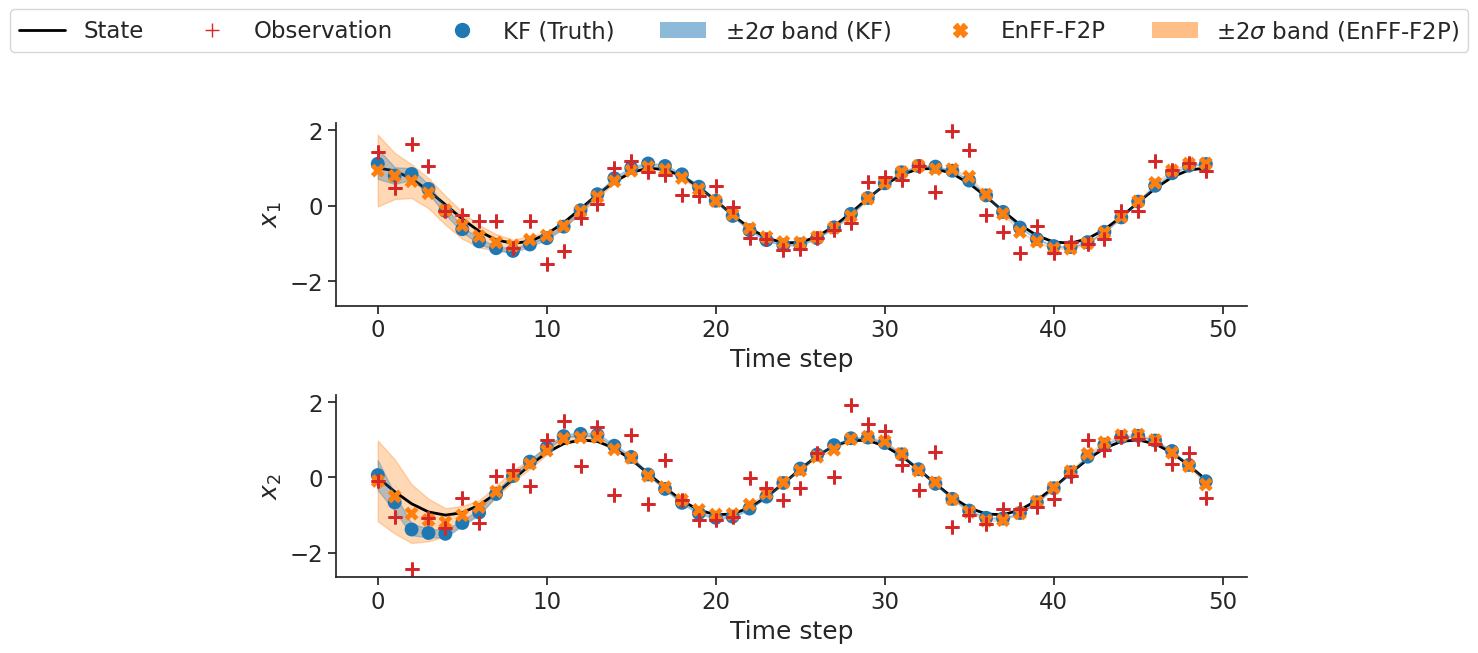

In [11]:
to_plot = duckdb.sql("""
select
    *
from filters
join df using (alt_id)
order by
    case hue
        when 'KF' then 1
        when 'EnFF-F2P' then 0
    end desc,
    row
""").pl()
print(to_plot)
markersize = 100
plot =(
    sns.relplot(
        kind='scatter',
        data=to_plot,
        **{k: k for k in to_plot.columns if k != 'alt_id'},
        height=3,
        aspect=3,
        # height=4,
        # aspect=3,
        s=markersize,
        linewidth=0,
        facet_kws=dict(
            sharex=False,
        )
    )
    .set_titles('')
    .set(
        xlabel='Time step',
        # xlim=(39.5,45.5),
        # ylim=(-1.5,1.5),
    )
)
for (row, col, hue), facet_data in plot.facet_data():
    ax = plot.axes[row, col]
    r = plot.row_names[row]
    ax.set_ylabel(r)
    # if r == '$x_1$':
    #     ax.set_ylim(-1.5, .5)
    # else:
    #     ax.set_ylim(-.5, 1.5)
    sns.scatterplot(
        data=obs_df.filter(row=r),
        x='x', y='y',
        color='tab:red',
        marker='+',
        legend=False,
        ax=ax,
        zorder=1,
        s=markersize,
        linewidth=2,
    )
    sns.lineplot(
        data=true_df.filter(row=r),
        x='x', y='y',
        color='black',
        ls='-',
        legend=False,
        ax=ax,
        zorder=-1,
        linewidth=2,
    )
    for hue in to_plot['hue'].unique():
        uncertainties = duckdb.sql(f"""
        select
           *
        from cov_df
        join filters using (alt_id)
        where hue = {hue!r} and row = {r!r}
        """).pl()
        bound = 2 * uncertainties[f'$C_{{{row+1}{row+1}}}$']
        ax.fill_between(
            uncertainties['x'],
            uncertainties['y'] - bound,
            uncertainties['y'] + bound,
            zorder=-1 if hue == 'KF' else -2,
            color='tab:blue' if hue == 'KF' else 'tab:orange',
            alpha=.3,
        )
# Get existing legend entries that seaborn already drew
legend_data = {}
if plot._legend is not None:
    # labels = [t.get_text() for t in plot._legend.get_texts()]
    # handles = plot._legend.legend_handles
    # legend_data = dict(zip(labels, handles))
    plot._legend.remove()  # remove old legend before rebuilding
    # pass
# Add your custom entries
legend_data["State"] = Line2D([], [], color="black", ls="-", lw=2)
legend_data["Observation"] = Line2D([], [], color="tab:red", marker="+", markersize=10, ls="None")
legend_data["KF (Truth)"] = Line2D([], [], color="tab:blue", marker="o", markersize=10,ls="None")
legend_data[r"$\pm 2\sigma$ band (KF)"] = Patch(facecolor="tab:blue", alpha=0.5, edgecolor="none")
legend_data["EnFF-F2P"] = Line2D([], [], color="tab:orange", marker="X", markersize=10, ls="None")
legend_data[r"$\pm 2\sigma$ band (EnFF-F2P)"] = Patch(facecolor="tab:orange", alpha=0.5, edgecolor="none")
plot.add_legend(legend_data=legend_data, title=None)
# sns.move_legend(plot, loc='upper center', ncol=len(legend_data))
sns.move_legend(
    plot,
    loc='upper center',
    ncol=len(legend_data),
    title='',
    # bbox_to_anchor=(.400, 1.18),
    bbox_to_anchor=(.400, 1.12),
    frameon=True,
    fancybox=True,
)

In [12]:
dafm.plots.save_all_subfigures(plot, 'Cmp.Rotation2D')